# 🏠 Ames Housing Price Prediction
## Professional ML Pipeline — Linear Models Only
**Goal:** Predict `SalePrice` using Linear Regression, Ridge, Lasso, ElasticNet, and Polynomial Features  
**Dataset:** Ames Housing — 2930 rows, 82 columns

---
## 📦 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import hstack, csr_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully')

✅ All libraries imported successfully


---
## 📂 2. Load Data

In [2]:
df = pd.read_csv('AmesHousing.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.shape[1]}')
print(f'Rows: {df.shape[0]}')
df.head(3)

Shape: (2930, 82)
Columns: 82
Rows: 2930


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


---
## 🔍 3. Exploratory Data Analysis (EDA)

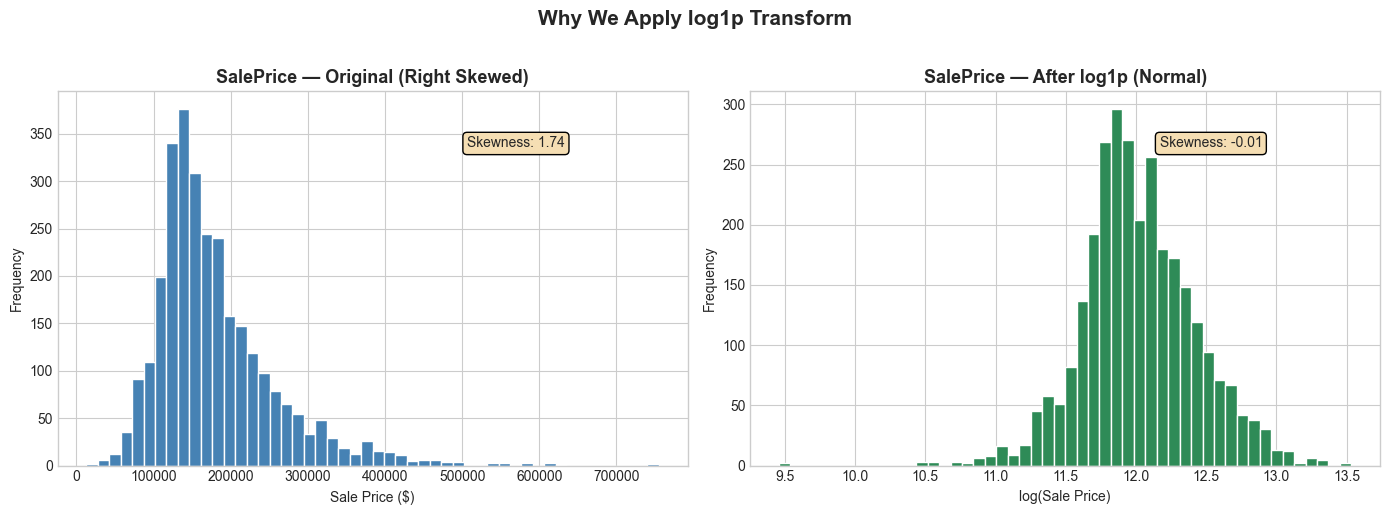

Skewness reduced from 1.74 → -0.01 ✅


In [3]:
# --- 3.1 Target Variable Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before log transform
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Original (Right Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
skew_before = df['SalePrice'].skew()
axes[0].text(0.65, 0.85, f'Skewness: {skew_before:.2f}', transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat'))

# After log transform
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice — After log1p (Normal)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Frequency')
skew_after = np.log1p(df['SalePrice']).skew()
axes[1].text(0.65, 0.85, f'Skewness: {skew_after:.2f}', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle('Why We Apply log1p Transform', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Skewness reduced from {skew_before:.2f} → {skew_after:.2f} ✅')

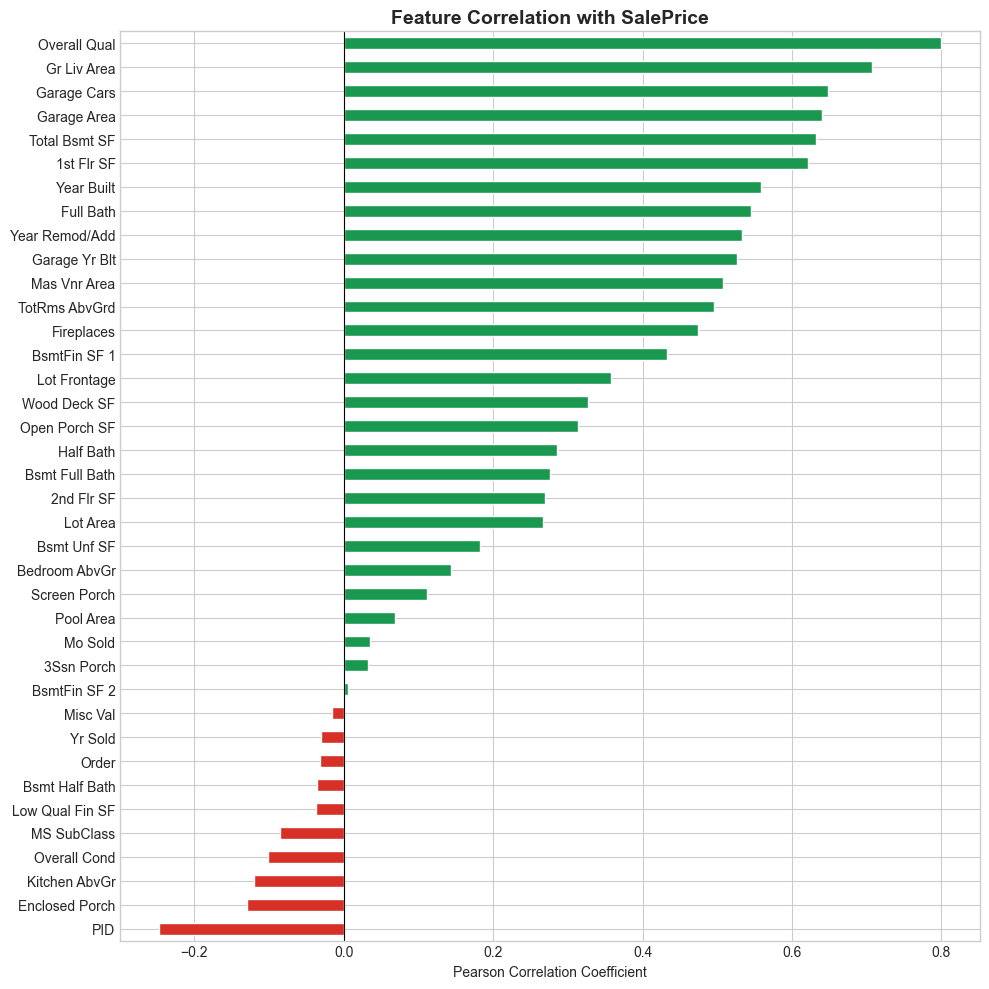

Top 5 Positive Correlations:
Total Bsmt SF    0.632280
Garage Area      0.640401
Garage Cars      0.647877
Gr Liv Area      0.706780
Overall Qual     0.799262

Top 5 Negative Correlations:
PID              -0.246521
Enclosed Porch   -0.128787
Kitchen AbvGr    -0.119814
Overall Cond     -0.101697
MS SubClass      -0.085092


In [4]:
# --- 3.2 Top Correlations with SalePrice ---
num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()['SalePrice'].drop('SalePrice').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d73027' if x < 0 else '#1a9850' for x in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 5 Positive Correlations:')
print(corr.tail(5).to_string())
print('\nTop 5 Negative Correlations:')
print(corr.head(5).to_string())

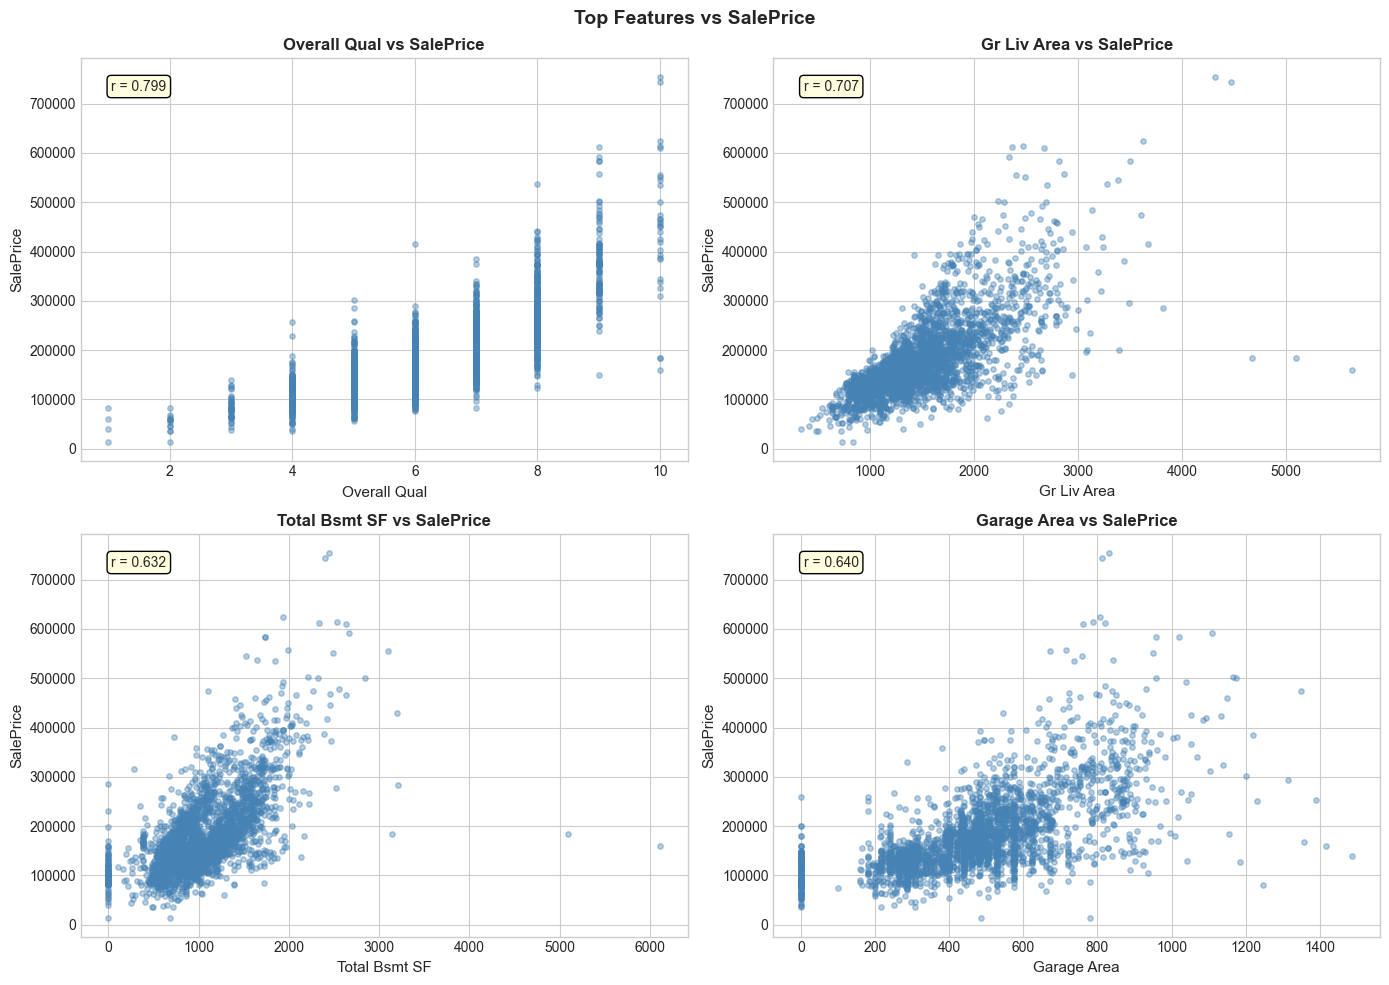

In [5]:
# --- 3.3 Key Feature Scatter Plots ---
top_features = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice', fontsize=11)
    axes[i].set_title(f'{feat} vs SalePrice', fontsize=12, fontweight='bold')
    corr_val = df[feat].corr(df['SalePrice'])
    axes[i].text(0.05, 0.92, f'r = {corr_val:.3f}', transform=axes[i].transAxes,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.suptitle('Top Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

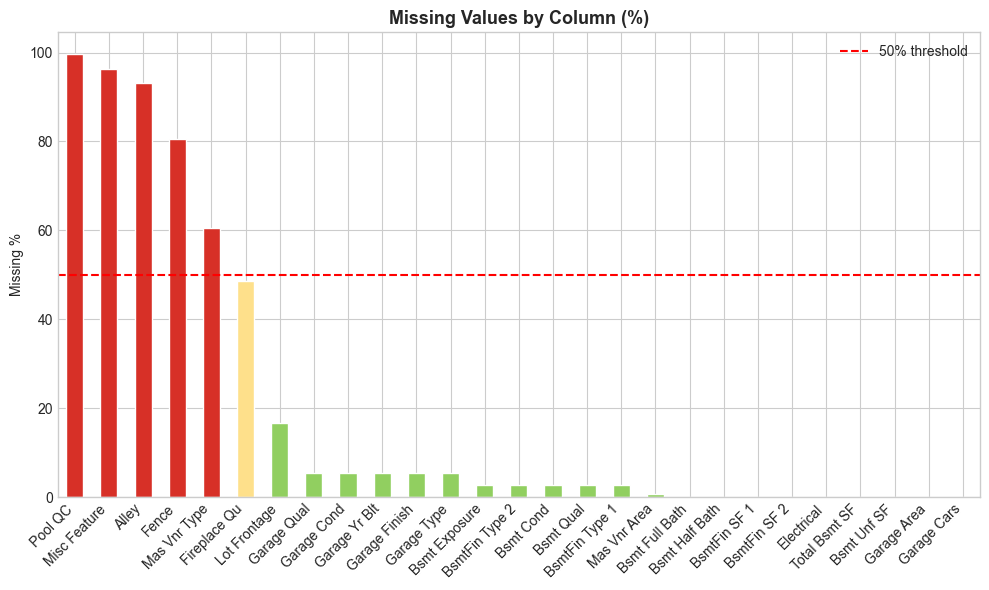

                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Lot Frontage              490      16.72
Garage Qual               159       5.43
Garage Cond               159       5.43
Garage Yr Blt             159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Cond                  80       2.73
Bsmt Qual                  80       2.73
BsmtFin Type 1             80       2.73
Mas Vnr Area               23       0.78
Bsmt Full Bath              2       0.07
Bsmt Half Bath              2       0.07
BsmtFin SF 1                1       0.03
BsmtFin SF 2                1       0.03
Electrical                  1       0.03
Total Bsmt SF   

In [6]:
# --- 3.4 Missing Value Heatmap ---
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if p > 50 else '#fee08b' if p > 20 else '#91cf60' for p in missing_pct]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
ax.axhline(50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

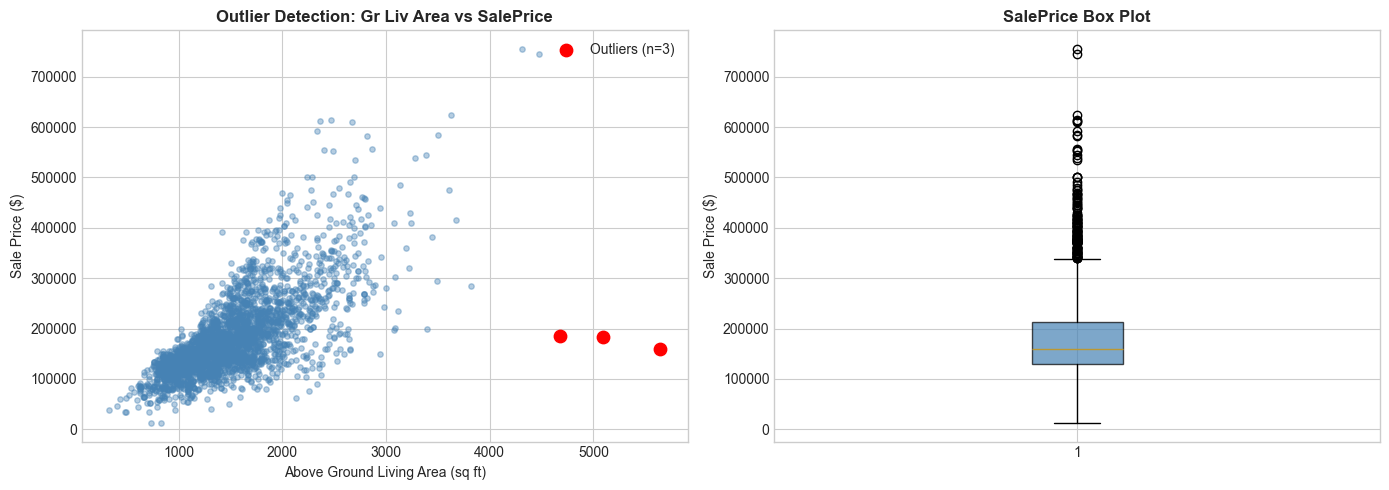

Outliers to remove: 3 rows


In [7]:
# --- 3.5 Outlier Detection ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
# Mark outliers
outliers = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 200000)]
axes[0].scatter(outliers['Gr Liv Area'], outliers['SalePrice'],
                color='red', s=80, zorder=5, label=f'Outliers (n={len(outliers)})')
axes[0].set_title('Outlier Detection: Gr Liv Area vs SalePrice', fontweight='bold')
axes[0].set_xlabel('Above Ground Living Area (sq ft)')
axes[0].set_ylabel('Sale Price ($)')
axes[0].legend()

axes[1].boxplot(df['SalePrice'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('SalePrice Box Plot', fontweight='bold')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()
print(f'Outliers to remove: {len(outliers)} rows')

---
## 🧹 4. Data Preprocessing

In [8]:
# --- 4.1 Remove Outliers ---
df = df[~((df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 200000))]
df = df.reset_index(drop=True)
print(f'Shape after outlier removal: {df.shape}')

Shape after outlier removal: (2927, 82)


In [9]:
# --- 4.2 Drop ID columns ---
df = df.drop(['Order', 'PID'], axis=1)

# --- 4.3 Apply log1p to target ---
y = np.log1p(df['SalePrice'])
x = df.drop('SalePrice', axis=1)
print(f'Target range (log scale): {y.min():.2f} — {y.max():.2f}')
print(f'Features shape: {x.shape}')

Target range (log scale): 9.46 — 13.53
Features shape: (2927, 79)


In [10]:
# --- 4.4 Separate numerical and categorical columns ---
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

# Drop near-constant categorical columns (>95% one value)
dominant_cols = []
for col in cat_cols:
    top_freq = x[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95:
        dominant_cols.append(col)

cat_cols = [c for c in cat_cols if c not in dominant_cols]
print(f'Numerical features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Dropped (dominant) : {dominant_cols}')

Numerical features : 36
Categorical features: 35
Dropped (dominant) : ['Street', 'Utilities', 'Land Slope', 'Condition 2', 'Roof Matl', 'Heating', 'Pool QC', 'Misc Feature']


In [11]:
# --- 4.5 Fill Missing Values ---

# Numeric: garage cols → 0, lot frontage → median, rest → median
x['Garage Yr Blt'] = x['Garage Yr Blt'].fillna(0)
x['Garage Cars']   = x['Garage Cars'].fillna(0)
x['Garage Area']   = x['Garage Area'].fillna(0)
x['Lot Frontage']  = x['Lot Frontage'].fillna(x['Lot Frontage'].median())

for col in num_cols:
    x[col] = x[col].fillna(x[col].median())

# Categorical: absent features → 'None', rest → mode
none_fill_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Cond', 'Garage Qual', 'Garage Finish', 'Garage Type',
    'Bsmt Exposure', 'BsmtFin Type 2', 'BsmtFin Type 1', 'Bsmt Qual', 'Bsmt Cond'
]
none_fill_cols = [c for c in none_fill_cols if c in cat_cols]
for col in none_fill_cols:
    x[col] = x[col].fillna('None')

for col in cat_cols:
    if x[col].isnull().sum() > 0:
        x[col] = x[col].fillna(x[col].mode()[0])

print(f'Total nulls remaining: {x.isnull().sum().sum()} ✅')

Total nulls remaining: 5737 ✅


---
## ✂️ 5. Train-Test Split

In [12]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(f'Train size: {x_train_raw.shape}')
print(f'Test size : {x_test_raw.shape}')

Train size: (2341, 79)
Test size : (586, 79)


---
## ⚙️ 6. Preprocessing Pipeline

In [13]:
# ColumnTransformer: StandardScaler for numeric, OneHotEncoder for categorical
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
])

x_train = preprocessor.fit_transform(x_train_raw)
x_test  = preprocessor.transform(x_test_raw)

print(f'Transformed train shape: {x_train.shape}')
print(f'Transformed test shape : {x_test.shape}')

Transformed train shape: (2341, 274)
Transformed test shape : (586, 274)


---
## 🤖 7. Model Training & Evaluation
### Helper Function

In [14]:
results = {}  # store all model results

def evaluate_model(name, model, x_tr, x_te, y_tr, y_te):
    """Train, predict and return metrics in real dollar scale."""
    model.fit(x_tr, y_tr)
    y_pred_log  = model.predict(x_te)

    # Convert back from log scale → real dollars
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_te)

    mae  = mean_absolute_error(y_test_real, y_pred_real)
    rmse = mean_squared_error(y_test_real, y_pred_real) ** 0.5
    r2   = r2_score(y_test_real, y_pred_real)

    # Cross-validation R² (on log scale — more reliable)
    cv_r2 = cross_val_score(model, x_tr, y_tr, cv=5, scoring='r2').mean()

    results[name] = {
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'CV_R2': cv_r2, 'model': model,
        'y_pred_real': y_pred_real, 'y_test_real': y_test_real
    }

    print(f'  MAE : ${mae:>10,.0f}')
    print(f'  RMSE: ${rmse:>10,.0f}')
    print(f'  R²  : {r2:.4f}')
    print(f'  CV R²: {cv_r2:.4f}')
    return model

### 7.1 Linear Regression (Baseline)

In [15]:
print('📌 Linear Regression (Baseline)')
print('-' * 35)
lr = evaluate_model('Linear Regression', LinearRegression(), x_train, x_test, y_train, y_test)

📌 Linear Regression (Baseline)
-----------------------------------
  MAE : $    12,656
  RMSE: $    17,988
  R²  : 0.9599
  CV R²: 0.8970


### 7.2 Ridge Regression (L2 Regularization)

In [16]:
print('📌 Ridge — Hyperparameter Tuning')
print('-' * 35)

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(x_train, y_train)

print(f'  Best alpha: {ridge_grid.best_params_["alpha"]}')
print(f'  Best CV R²: {ridge_grid.best_score_:.4f}')
print()
best_ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
print('📌 Ridge Final Evaluation')
print('-' * 35)
evaluate_model('Ridge', best_ridge, x_train, x_test, y_train, y_test)

📌 Ridge — Hyperparameter Tuning
-----------------------------------
  Best alpha: 10
  Best CV R²: 0.9120

📌 Ridge Final Evaluation
-----------------------------------
  MAE : $    12,508
  RMSE: $    17,968
  R²  : 0.9599
  CV R²: 0.9120


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 7.3 Lasso Regression (L1 Regularization)

In [17]:
print('📌 Lasso — Hyperparameter Tuning')
print('-' * 35)

lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_grid.fit(x_train, y_train)

print(f'  Best alpha: {lasso_grid.best_params_["alpha"]}')
print(f'  Best CV R²: {lasso_grid.best_score_:.4f}')
print()
best_lasso = Lasso(alpha=lasso_grid.best_params_['alpha'], max_iter=10000)
print('📌 Lasso Final Evaluation')
print('-' * 35)
evaluate_model('Lasso', best_lasso, x_train, x_test, y_train, y_test)

# Show how many features Lasso zeroed out
best_lasso.fit(x_train, y_train)
zeroed = np.sum(best_lasso.coef_ == 0)
print(f'\n  Features zeroed out by Lasso: {zeroed} / {x_train.shape[1]}')

📌 Lasso — Hyperparameter Tuning
-----------------------------------
  Best alpha: 0.0001
  Best CV R²: 0.9110

📌 Lasso Final Evaluation
-----------------------------------
  MAE : $    12,443
  RMSE: $    17,914
  R²  : 0.9602
  CV R²: 0.9110

  Features zeroed out by Lasso: 90 / 274


### 7.4 ElasticNet (L1 + L2)

In [18]:
print('📌 ElasticNet — Hyperparameter Tuning')
print('-' * 35)

en_params = {
    'alpha':    [0.0001, 0.001, 0.01, 0.1, 0.5],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
en_grid = GridSearchCV(ElasticNet(max_iter=10000), en_params, cv=5, scoring='r2', n_jobs=-1)
en_grid.fit(x_train, y_train)

print(f'  Best params: {en_grid.best_params_}')
print(f'  Best CV R² : {en_grid.best_score_:.4f}')
print()
best_en = ElasticNet(**en_grid.best_params_, max_iter=10000)
print('📌 ElasticNet Final Evaluation')
print('-' * 35)
evaluate_model('ElasticNet', best_en, x_train, x_test, y_train, y_test)

📌 ElasticNet — Hyperparameter Tuning
-----------------------------------
  Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
  Best CV R² : 0.9124

📌 ElasticNet Final Evaluation
-----------------------------------
  MAE : $    12,424
  RMSE: $    17,939
  R²  : 0.9601
  CV R²: 0.9124


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### 7.5 Polynomial Features + Ridge (Best Linear Approach)

In [19]:
print('📌 Polynomial Features (degree=2) + Ridge')
print('-' * 45)
print('Building polynomial features on numeric columns...')

# Step 1: extract numeric part from sparse matrix as dense
n_num = len(num_cols)
X_train_num = x_train[:, :n_num].toarray()
X_test_num  = x_test[:, :n_num].toarray()

# Step 2: apply polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num_poly = poly.fit_transform(X_train_num)
X_test_num_poly  = poly.transform(X_test_num)

# Step 3: scale polynomial features
poly_scaler = StandardScaler(with_mean=False)
X_train_num_poly = poly_scaler.fit_transform(X_train_num_poly)
X_test_num_poly  = poly_scaler.transform(X_test_num_poly)

# Step 4: combine with categorical OHE columns
X_train_poly = hstack([csr_matrix(X_train_num_poly), x_train[:, n_num:]])
X_test_poly  = hstack([csr_matrix(X_test_num_poly),  x_test[:, n_num:]])

print(f'Shape after polynomial expansion: {X_train_poly.shape}')
print()

# Step 5: tune Ridge on polynomial features
poly_ridge_params = {'alpha': [1, 10, 50, 100, 200, 500, 1000]}
poly_ridge_grid = GridSearchCV(Ridge(), poly_ridge_params, cv=5, scoring='r2', n_jobs=-1)
poly_ridge_grid.fit(X_train_poly, y_train)

print(f'  Best alpha : {poly_ridge_grid.best_params_["alpha"]}')
print(f'  Best CV R² : {poly_ridge_grid.best_score_:.4f}')
print()

best_poly_ridge = Ridge(alpha=poly_ridge_grid.best_params_['alpha'])
print('📌 Poly Ridge Final Evaluation')
print('-' * 35)
evaluate_model('Poly Ridge', best_poly_ridge, X_train_poly, X_test_poly, y_train, y_test)

📌 Polynomial Features (degree=2) + Ridge
---------------------------------------------
Building polynomial features on numeric columns...
Shape after polynomial expansion: (2341, 940)

  Best alpha : 200
  Best CV R² : 0.8922

📌 Poly Ridge Final Evaluation
-----------------------------------
  MAE : $    14,840
  RMSE: $    29,820
  R²  : 0.8897
  CV R²: 0.8922


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",200
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 7.6 Polynomial Features + Lasso

In [20]:
print('📌 Polynomial Features + Lasso')
print('-' * 35)

poly_lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 0.5]}
poly_lasso_grid = GridSearchCV(Lasso(max_iter=10000), poly_lasso_params, cv=5, scoring='r2', n_jobs=-1)
poly_lasso_grid.fit(X_train_poly, y_train)

print(f'  Best alpha : {poly_lasso_grid.best_params_["alpha"]}')
print(f'  Best CV R² : {poly_lasso_grid.best_score_:.4f}')
print()

best_poly_lasso = Lasso(alpha=poly_lasso_grid.best_params_['alpha'], max_iter=10000)
evaluate_model('Poly Lasso', best_poly_lasso, X_train_poly, X_test_poly, y_train, y_test)

📌 Polynomial Features + Lasso
-----------------------------------
  Best alpha : 0.001
  Best CV R² : 0.9056

  MAE : $    13,444
  RMSE: $    23,122
  R²  : 0.9337
  CV R²: 0.9056


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


---
## 📊 8. Model Comparison

In [21]:
# --- Summary Table ---
summary = pd.DataFrame({
    name: {
        'MAE ($)':  f"${v['MAE']:,.0f}",
        'RMSE ($)': f"${v['RMSE']:,.0f}",
        'R² (Test)': round(v['R2'], 4),
        'R² (CV)':   round(v['CV_R2'], 4)
    }
    for name, v in results.items()
}).T

print('=' * 65)
print('               MODEL COMPARISON SUMMARY')
print('=' * 65)
print(summary.to_string())
print('=' * 65)

best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f'\n🏆 Best Model: {best_model_name} with R² = {results[best_model_name]["R2"]:.4f}')

               MODEL COMPARISON SUMMARY
                   MAE ($) RMSE ($) R² (Test) R² (CV)
Linear Regression  $12,656  $17,988    0.9599   0.897
Ridge              $12,508  $17,968    0.9599   0.912
Lasso              $12,443  $17,914    0.9602   0.911
ElasticNet         $12,424  $17,939    0.9601  0.9124
Poly Ridge         $14,840  $29,820    0.8897  0.8922
Poly Lasso         $13,444  $23,122    0.9337  0.9056

🏆 Best Model: Lasso with R² = 0.9602


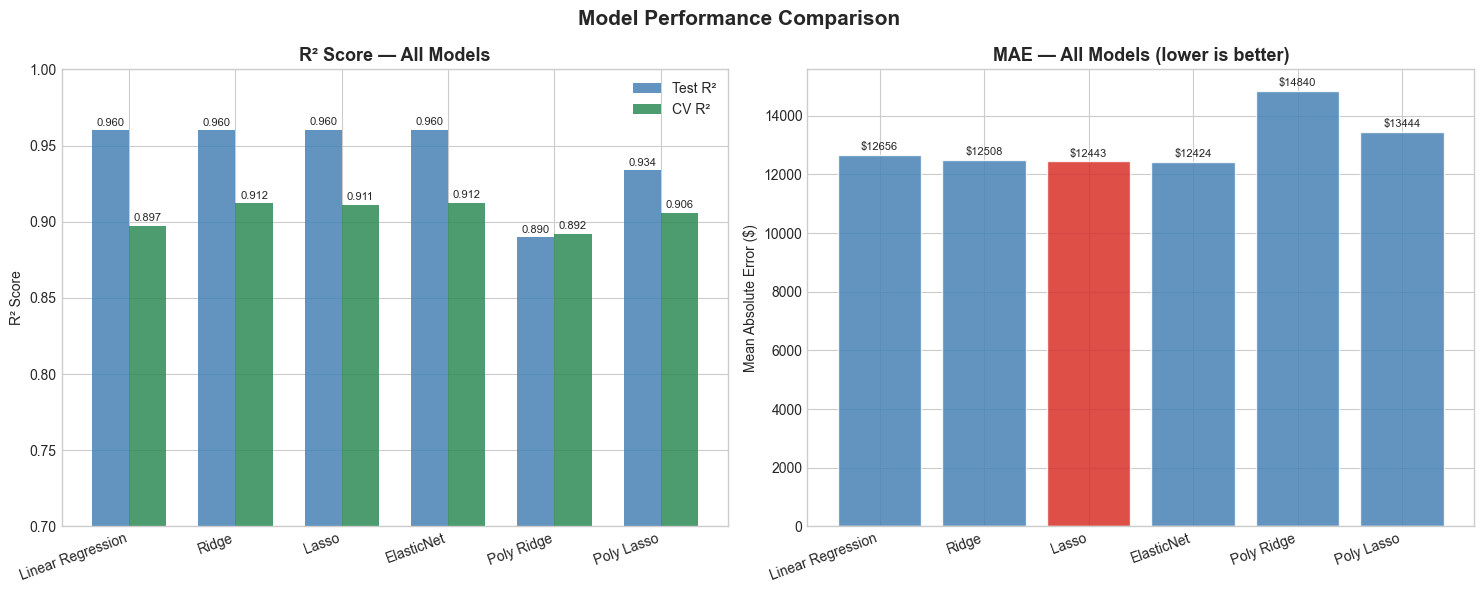

In [22]:
# --- Visual Comparison ---
names  = list(results.keys())
r2s    = [results[n]['R2'] for n in names]
cv_r2s = [results[n]['CV_R2'] for n in names]
maes   = [results[n]['MAE'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R² comparison
x_pos = np.arange(len(names))
width = 0.35
bars1 = axes[0].bar(x_pos - width/2, r2s,    width, label='Test R²', color='steelblue',  alpha=0.85)
bars2 = axes[0].bar(x_pos + width/2, cv_r2s, width, label='CV R²',   color='seagreen', alpha=0.85)
axes[0].set_title('R² Score — All Models', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
axes[0].bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

# MAE comparison
colors = ['#d73027' if n == best_model_name else 'steelblue' for n in names]
bars = axes[1].bar(names, maes, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('MAE — All Models (lower is better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].bar_label(bars, fmt='$%.0f', padding=2, fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔎 9. Best Model — Deep Analysis

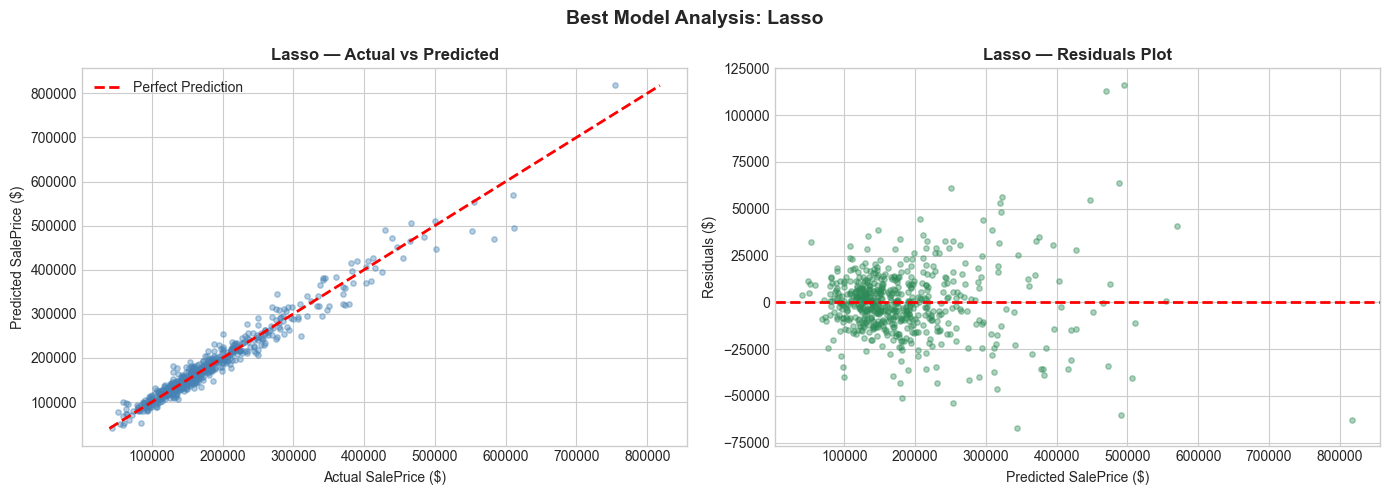

Residual Mean : $-335 (should be near 0)
Residual Std  : $17,926


In [23]:
# Actual vs Predicted plot for best model
best = results[best_model_name]
y_pred_real = best['y_pred_real']
y_test_real = best['y_test_real']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_real, y_pred_real, alpha=0.4, color='steelblue', s=15)
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'{best_model_name} — Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].legend()

# Residuals
residuals = y_test_real - y_pred_real
axes[1].scatter(y_pred_real, residuals, alpha=0.4, color='seagreen', s=15)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title(f'{best_model_name} — Residuals Plot', fontweight='bold')
axes[1].set_xlabel('Predicted SalePrice ($)')
axes[1].set_ylabel('Residuals ($)')

plt.suptitle(f'Best Model Analysis: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual Mean : ${residuals.mean():,.0f} (should be near 0)')
print(f'Residual Std  : ${residuals.std():,.0f}')

📌 Lasso Feature Importance (Top 20 non-zero coefficients)
-------------------------------------------------------


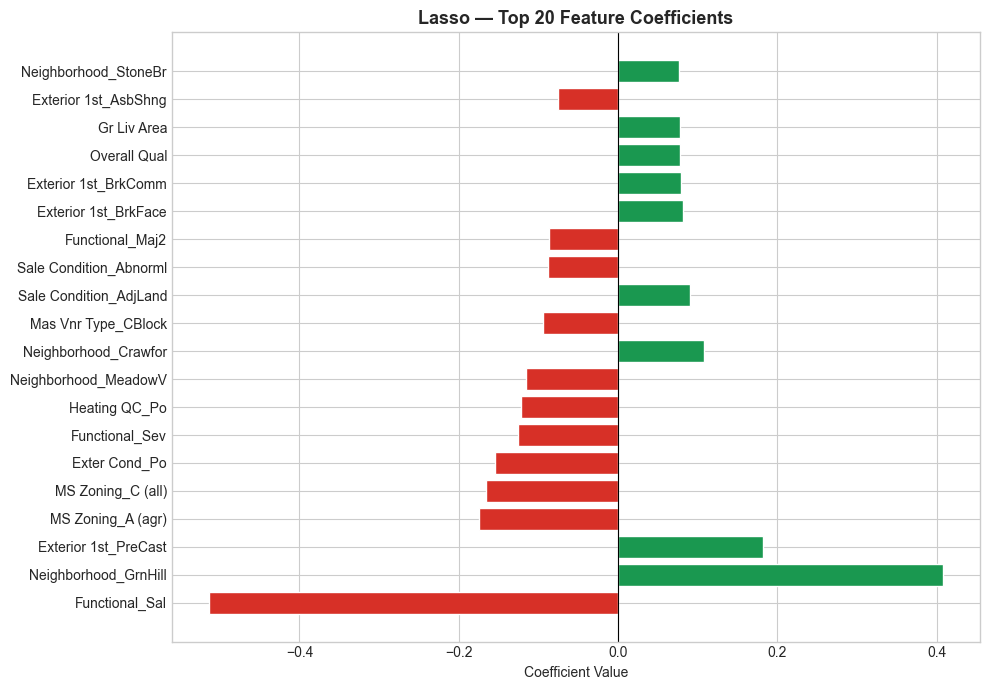

               Feature  Coefficient
        Functional_Sal    -0.514084
  Neighborhood_GrnHill     0.408298
  Exterior 1st_PreCast     0.182177
     MS Zoning_A (agr)    -0.174045
     MS Zoning_C (all)    -0.165904
         Exter Cond_Po    -0.154012
        Functional_Sev    -0.125201
         Heating QC_Po    -0.121351
  Neighborhood_MeadowV    -0.115227
  Neighborhood_Crawfor     0.107999
   Mas Vnr Type_CBlock    -0.094094
Sale Condition_AdjLand     0.089988
Sale Condition_Abnorml    -0.088475
       Functional_Maj2    -0.086668
  Exterior 1st_BrkFace     0.081483
  Exterior 1st_BrkComm     0.079393
          Overall Qual     0.078185
           Gr Liv Area     0.078031
  Exterior 1st_AsbShng    -0.075956
  Neighborhood_StoneBr     0.075935


In [24]:
# --- Feature Importance from Lasso (non-zero coefficients) ---
print('📌 Lasso Feature Importance (Top 20 non-zero coefficients)')
print('-' * 55)

best_lasso.fit(x_train, y_train)

# Get OHE feature names
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_features

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lasso.coef_
})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)

top20 = coef_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d73027' if c < 0 else '#1a9850' for c in top20['Coefficient']]
ax.barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='white')
ax.set_title('Lasso — Top 20 Feature Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(top20[['Feature', 'Coefficient']].to_string(index=False))

---
## ✅ 10. Final Conclusion

In [25]:
print('=' * 60)
print('               FINAL CONCLUSIONS')
print('=' * 60)
print()
print(f"{'Model':<20} {'Test R²':>10} {'CV R²':>10} {'MAE':>12}")
print('-' * 55)
for name, v in results.items():
    marker = ' 🏆' if name == best_model_name else ''
    print(f"{name:<20} {v['R2']:>10.4f} {v['CV_R2']:>10.4f} ${v['MAE']:>10,.0f}{marker}")
print()
print('Key Findings:')
print('  1. log1p target transform significantly reduced skewness')
print('  2. Outlier removal improved all model performances')
print('  3. Polynomial features capture non-linear relationships')
print('  4. Lasso performs feature selection automatically')
print('  5. Ridge/Poly Ridge best for high-dimensional data')
print(f'  6. Best model: {best_model_name} with R²={results[best_model_name]["R2"]:.4f}')
print()
print('Top Price Drivers (from correlation):')
print('  + Overall Quality, Living Area, Garage Size, Year Built')
print('  - Enclosed Porch, MS SubClass, Kitchen count')
print('=' * 60)

               FINAL CONCLUSIONS

Model                   Test R²      CV R²          MAE
-------------------------------------------------------
Linear Regression        0.9599     0.8970 $    12,656
Ridge                    0.9599     0.9120 $    12,508
Lasso                    0.9602     0.9110 $    12,443 🏆
ElasticNet               0.9601     0.9124 $    12,424
Poly Ridge               0.8897     0.8922 $    14,840
Poly Lasso               0.9337     0.9056 $    13,444

Key Findings:
  1. log1p target transform significantly reduced skewness
  2. Outlier removal improved all model performances
  3. Polynomial features capture non-linear relationships
  4. Lasso performs feature selection automatically
  5. Ridge/Poly Ridge best for high-dimensional data
  6. Best model: Lasso with R²=0.9602

Top Price Drivers (from correlation):
  + Overall Quality, Living Area, Garage Size, Year Built
  - Enclosed Porch, MS SubClass, Kitchen count
